# Glutamate activation QC

Inspect per-synapse activation/deactivation calls and response magnitudes.

In [34]:
import os
import glob
import json
import numpy as np
import pandas as pd
from pathlib import Path
from PNW_cmap import PNW_cmap
import matplotlib.pyplot as plt
from vip_slap2_analysis.utils.utils import save_figure
from vip_slap2_analysis.io.session_registry import VIPSessionRegistry
from vip_slap2_analysis.glutamate.summary import GlutamateSummary

import seaborn as sns
sns.set_style('white')
params = {'legend.fontsize': 'x-large',
         'axes.labelsize': 'xx-large',
         'axes.titlesize':'xx-large',
         'xtick.labelsize':'xx-large',
         'ytick.labelsize':'xx-large'}
plt.rcParams.update(params)

from IPython.display import display, HTML
display(HTML("<style>.container { width:100% !important; }</style>"))

In [53]:
%matplotlib notebook

In [46]:
save_path = r"C:\Users\andrew.shelton\Dropbox\allen institute\Documents\Presentations\OPhys\Lab_Meetings\2026-03-17_OPhys_LabMeetingIV\figures"

In [36]:
target_mice = [
    803496,
    804730,804733,810196,
    809047,803121,
    826033,838410,834788
]

In [37]:
registry = VIPSessionRegistry.from_basepath(
    r'\\allen\aind\scratch\ophys\Andrew\VIP_synaptic_dynamics'
)

process_df = registry.sessions(
    subject_ids=target_mice,
    exclude_session_types=["expression_check","volume_imaging"],
    paradigms=["change_detection_passive"],
)

assets = [registry.resolve_assets(row) for _, row in process_df.iterrows()]

In [38]:
assets[0].metadata

{'session_id': '803496_2025-07-25_13-02-10',
 'subject_id': 803496,
 'session_#': 2,
 'session_date': Timestamp('2025-07-25 00:00:00'),
 'indicator1': 'iGluSnFR4',
 'indicator2': nan,
 'dmd1_depth': 25,
 'dmd2_depth': 100,
 'paradigm': 'change_detection_passive',
 'session_type': 'familiar',
 'stimulus': 'images_A',
 'experimentor': 'Andrew Shelton',
 'instrument_name': 'slap2_albert',
 'instrument_id': 'SLAP2_1',
 'camera_type': 'vimba',
 'has raster ROI?': 'yes',
 'has integration roi?': 'no',
 'behavior_rig': 'VCO.1',
 'quality': 'good',
 'flags': nan,
 'session_dir': WindowsPath('//allen/aind/scratch/ophys/Andrew/VIP_synaptic_dynamics/iGluSnFR4f/803496/2025-07-25_803496'),
 'purpose': nan,
 'notes': nan}

In [39]:
# -----------------------------
# helpers
# -----------------------------

def normalize_dmd(x):
    s = str(x).strip().upper()
    if s in {"1", "1.0", "DMD1"}:
        return 1
    elif s in {"2", "2.0", "DMD2"}:
        return 2
    return np.nan

def find_activation_summary_csv(asset):
    """
    Find the per-session activation summary table.
    Searches derived_dir first, then qc_dir, then session_dir.
    """
    search_roots = [
        getattr(asset, "derived_dir", None),
        getattr(asset, "qc_dir", None),
        getattr(asset, "session_dir", None),
    ]
    patterns = [
        "activation_summary_table.csv",
        "*activation*summary*.csv",
    ]

    matches = []
    for root in search_roots:
        if root is None:
            continue
        root = Path(root)
        for pat in patterns:
            matches.extend(glob.glob(str(root / "**" / pat), recursive=True))

    matches = sorted(set(matches))
    if not matches:
        return None

    # prefer most recently modified if multiple
    return Path(max(matches, key=os.path.getmtime))


def infer_dmd_depth_map(asset):
    meta = getattr(asset, "metadata", {}) or {}
    return {
        1: pd.to_numeric(meta.get("dmd1_depth", np.nan), errors="coerce"),
        2: pd.to_numeric(meta.get("dmd2_depth", np.nan), errors="coerce"),
    }

def build_activation_image_df(assets):
    dfs = []
    missing = []

    for asset in assets:
        csv_path = find_activation_summary_csv(asset)
        if csv_path is None:
            missing.append(getattr(asset, "session_id", "unknown"))
            continue

        df = pd.read_csv(csv_path)

        if "stimulus_family" not in df.columns:
            print(f"[warn] stimulus_family missing in {csv_path}")
            continue

        dfi = df.loc[df["stimulus_family"].astype(str).str.lower() == "image"].copy()
        if dfi.empty:
            continue

        meta = getattr(asset, "metadata", {}) or {}
        dmd_depth_map = infer_dmd_depth_map(asset)

        dfi["session_id"] = getattr(asset, "session_id", meta.get("session_id", np.nan))
        dfi["subject_id"] = getattr(asset, "subject_id", meta.get("subject_id", np.nan))
        dfi["session_type"] = meta.get("session_type", np.nan)
        dfi["session_date"] = meta.get("session_date", np.nan)
        dfi["paradigm"] = meta.get("paradigm", np.nan)

        if "dmd" not in dfi.columns:
            raise ValueError(f"'dmd' column missing from {csv_path}")

        dfi["dmd_norm"] = dfi["dmd"].apply(normalize_dmd)
        dfi["depth_um"] = dfi["dmd_norm"].map(dmd_depth_map)

        # optional debugging
        if dfi["depth_um"].isna().all():
            print(f"[warn] all depth_um NaN for {csv_path}")
            print("depth map:", dmd_depth_map)
            print("unique raw dmd:", dfi["dmd"].unique())
            print("unique normalized dmd:", dfi["dmd_norm"].unique())

        dfi["activation_summary_csv"] = str(csv_path)

        dfs.append(dfi)

    if not dfs:
        raise ValueError("No activation summary tables were found / loaded.")

    out = pd.concat(dfs, ignore_index=True)

    if "session_date" in out.columns:
        out["session_date"] = pd.to_datetime(out["session_date"], errors="coerce")

    return out, missing

In [40]:
activation_image_df, missing_sessions = build_activation_image_df(assets)

print("shape:", activation_image_df.shape)
print("missing sessions:", missing_sessions)
print("columns:", activation_image_df.columns.tolist())

activation_image_df.head()

shape: (6992, 18)
missing sessions: []
columns: ['session_id', 'subject_id', 'dmd', 'synapse_id', 'stimulus_family', 'n_events', 'median_delta_auc', 'mean_delta_auc', 'effect_direction', 'p_value', 'response_class', 'q_value_within_synapse', 'session_type', 'session_date', 'paradigm', 'dmd_norm', 'depth_um', 'activation_summary_csv']


,session_id,subject_id,dmd,synapse_id,stimulus_family,n_events,median_delta_auc,mean_delta_auc,effect_direction,p_value,response_class,q_value_within_synapse,session_type,session_date,paradigm,dmd_norm,depth_um,activation_summary_csv
0,803496_2025-07-25_13-02-10,803496,DMD1,DMD1_syn0000,image,2277,-20.015213,-23.085767,none,3.356907e-02,no_change,1.007072e-01,familiar,2025-07-25,change_detection_passive,1,25,\\allen\aind\scratch\ophys\Andrew\VIP_synaptic...
1,803496_2025-07-25_13-02-10,803496,DMD1,DMD1_syn0001,image,2277,11.062568,10.113008,none,1.885622e-01,no_change,3.431282e-01,familiar,2025-07-25,change_detection_passive,1,25,\\allen\aind\scratch\ophys\Andrew\VIP_synaptic...
2,803496_2025-07-25_13-02-10,803496,DMD1,DMD1_syn0002,image,2277,62.247024,75.345806,up,1.833899e-10,activated,5.501698e-10,familiar,2025-07-25,change_detection_passive,1,25,\\allen\aind\scratch\ophys\Andrew\VIP_synaptic...
3,803496_2025-07-25_13-02-10,803496,DMD1,DMD1_syn0003,image,2277,51.070708,94.594795,up,5.779422e-15,activated,1.733827e-14,familiar,2025-07-25,change_detection_passive,1,25,\\allen\aind\scratch\ophys\Andrew\VIP_synaptic...
4,803496_2025-07-25_13-02-10,803496,DMD1,DMD1_syn0004,image,2277,-94.736861,-159.029189,down,1.601894e-34,deactivated,4.805682e-34,familiar,2025-07-25,change_detection_passive,1,25,\\allen\aind\scratch\ophys\Andrew\VIP_synaptic...


In [66]:
activation_image_df.to_csv(os.path.join(save_path,'activation_df.csv'))

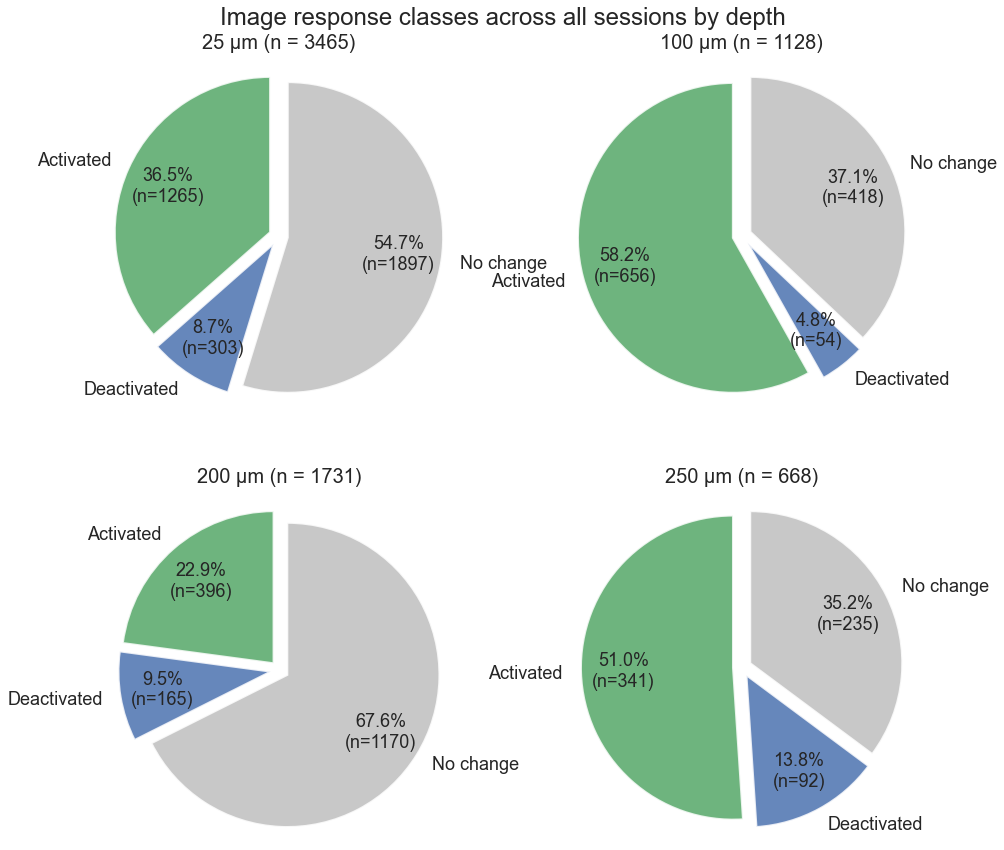

In [49]:
from collections import Counter

# -----------------------------------
# expected input: activation_image_df
# columns needed:
#   - depth_um
#   - response_class
# -----------------------------------

plot_df = activation_image_df.copy()

# keep canonical classes only
plot_df["response_class"] = (
    plot_df["response_class"]
    .astype(str)
    .str.strip()
    .str.lower()
)

class_order = ["activated", "deactivated", "no_change"]
class_label_map = {
    "activated": "Activated",
    "deactivated": "Deactivated",
    "no_change": "No change",
    "no change": "No change",
}
class_color_map = {
    "activated": "#55A868",   # green
    "deactivated": "#4C72B0", # blue
    "no_change": "#BFBFBF",   # gray
    "no change": "#BFBFBF",
}

# normalize label variants
plot_df["response_class"] = plot_df["response_class"].replace({
    "no change": "no_change"
})

# keep only expected depths
depths = [25, 100, 200, 250]
plot_df = plot_df[plot_df["depth_um"].isin(depths)].copy()

fig, ax = plt.subplots(2, 2, figsize=(14, 12))
axes = ax.flatten()

for i, depth in enumerate(depths):
    axis = axes[i]
    sub = plot_df[plot_df["depth_um"] == depth].copy()

    counts = Counter(sub["response_class"].values)

    # fixed order so colors are consistent across depths
    order = [c for c in class_order if counts.get(c, 0) > 0]
    sizes = [counts[c] for c in order]
    total_n = sum(sizes)

    def _autopct(pct):
        n = int(round(pct * total_n / 100.0))
        return f"{pct:.1f}%\n(n={n})" if n > 0 else ""

    wedges, texts, autotexts = axis.pie(
        sizes,
        labels=[class_label_map[c] for c in order],
        colors=[class_color_map[c] for c in order],
        explode=[0.06] * len(order),
        startangle=90,
        counterclock=True,
        autopct=_autopct,
        pctdistance=0.72,
        labeldistance=1.12,
        wedgeprops=dict(edgecolor="w", linewidth=2, alpha=0.85),
        textprops=dict(fontsize=18),
    )

    axis.set_title(f"{depth} µm (n = {total_n})", fontsize=20, y=1.02)
    axis.axis("equal")

fig.suptitle("Image response classes across all sessions by depth", fontsize=24, y=0.98)
fig.tight_layout()
fig.subplots_adjust(hspace=0.25, wspace=0.15)

filen = f"ResponseClassPie_ByDepth"
savepath = os.path.join(save_path, filen)
save_figure(fig, savepath, formats=[".pdf", ".png"], dpi=300)

In [30]:
infer_dmd_depth_map(assets[0])

{1: 25.0, 2: 100.0}

In [64]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# -----------------------------------------
# expected line colors
# -----------------------------------------
cl, cmap, cp = PNW_cmap.get_PNW_cmap('Sunset2', n_colors=10)
cp = [cp[::-1][0], cp[::-1][4], cp[::-1][7], cp[::-1][9]]

depth_order = [25, 100, 200, 250]
depth_color_map = dict(zip(depth_order, cp))

# -----------------------------------------
# prep dataframe
# -----------------------------------------
df = activation_image_df.copy()

df["session_type"] = (
    df["session_type"]
    .astype(str)
    .str.strip()
    .str.lower()
    .replace({
        "familiar": "f",
        "novel": "n",
        "novel+": "n+",
        "novel_plus": "n+",
    })
)

df["response_class"] = (
    df["response_class"]
    .astype(str)
    .str.strip()
    .str.lower()
    .replace({"no change": "no_change"})
)

df["session_date"] = pd.to_datetime(df["session_date"], errors="coerce")
df["depth_um"] = pd.to_numeric(df["depth_um"], errors="coerce")

# keep only expected session types / depths
df = df[df["session_type"].isin(["f", "n", "n+"])]
df = df[df["depth_um"].isin(depth_order)]

# -----------------------------------------
# optional dedup to one row per unique synapse within session
# if synapse_id exists, use it
# -----------------------------------------
if "synapse_id" in df.columns:
    dedup_cols = ["subject_id", "session_id", "depth_um", "synapse_id"]
    # keep first row per synapse/session/depth
    df = df.sort_values(["subject_id", "session_date", "session_id"]).drop_duplicates(dedup_cols)

# -----------------------------------------
# choose last 6 sessions per animal
# -----------------------------------------
session_meta = (
    df[["subject_id", "session_id", "session_date", "session_type"]]
    .drop_duplicates()
    .sort_values(["subject_id", "session_date", "session_id"])
)

last6 = (
    session_meta
    .groupby("subject_id", group_keys=False)
    .apply(lambda x: x.sort_values(["session_date", "session_id"]).tail(6))
    .reset_index(drop=True)
)

# assign canonical slots in chronological order
slot_labels = ["f1", "f2", "f3", "n", "n+1", "n+2"]
last6["session_slot"] = last6.groupby("subject_id").cumcount().map(dict(enumerate(slot_labels)))

# sanity check: compare actual session_type sequence to expected
expected_type_by_slot = {
    "f1": "f",
    "f2": "f",
    "f3": "f",
    "n": "n",
    "n+1": "n+",
    "n+2": "n+",
}
last6["expected_type"] = last6["session_slot"].map(expected_type_by_slot)
last6["matches_expected"] = last6["session_type"] == last6["expected_type"]

mismatch = last6.loc[~last6["matches_expected"], ["subject_id", "session_id", "session_type", "session_slot"]]
if len(mismatch):
    print("Warning: some animals' last 6 sessions do not match the expected f,f,f,n,n+,n+ pattern")
    display(mismatch)

# keep only sessions in last6
plot_df = df.merge(
    last6[["subject_id", "session_id", "session_slot"]],
    on=["subject_id", "session_id"],
    how="inner"
)

# -----------------------------------------
# compute per-animal % activated for each slot x depth
# -----------------------------------------
plot_df["is_activated"] = plot_df["response_class"].eq("activated").astype(float)

animal_slot_depth = (
    plot_df
    .groupby(["subject_id", "session_slot", "depth_um"], as_index=False)
    .agg(
        pct_activated=("is_activated", lambda x: 100 * np.nanmean(x)),
        n_synapses=("is_activated", "size"),
    )
)

# order slots
slot_order = ["f1", "f2", "f3", "n", "n+1", "n+2"]
animal_slot_depth["session_slot"] = pd.Categorical(
    animal_slot_depth["session_slot"],
    categories=slot_order,
    ordered=True,
)

C:\Users\andrew.shelton\AppData\Local\Temp\ipykernel_51648\2199625829.py:67: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  session_meta


,subject_id,session_id,session_type,session_slot
51,838410,838410_2026-03-20_10-00-59,n+,n
52,838410,838410_2026-03-18_16-43-23,n,n+1


C:\Users\andrew.shelton\AppData\Local\Temp\ipykernel_51648\193157176.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  animal_slot_depth


<IPython.core.display.Javascript object>


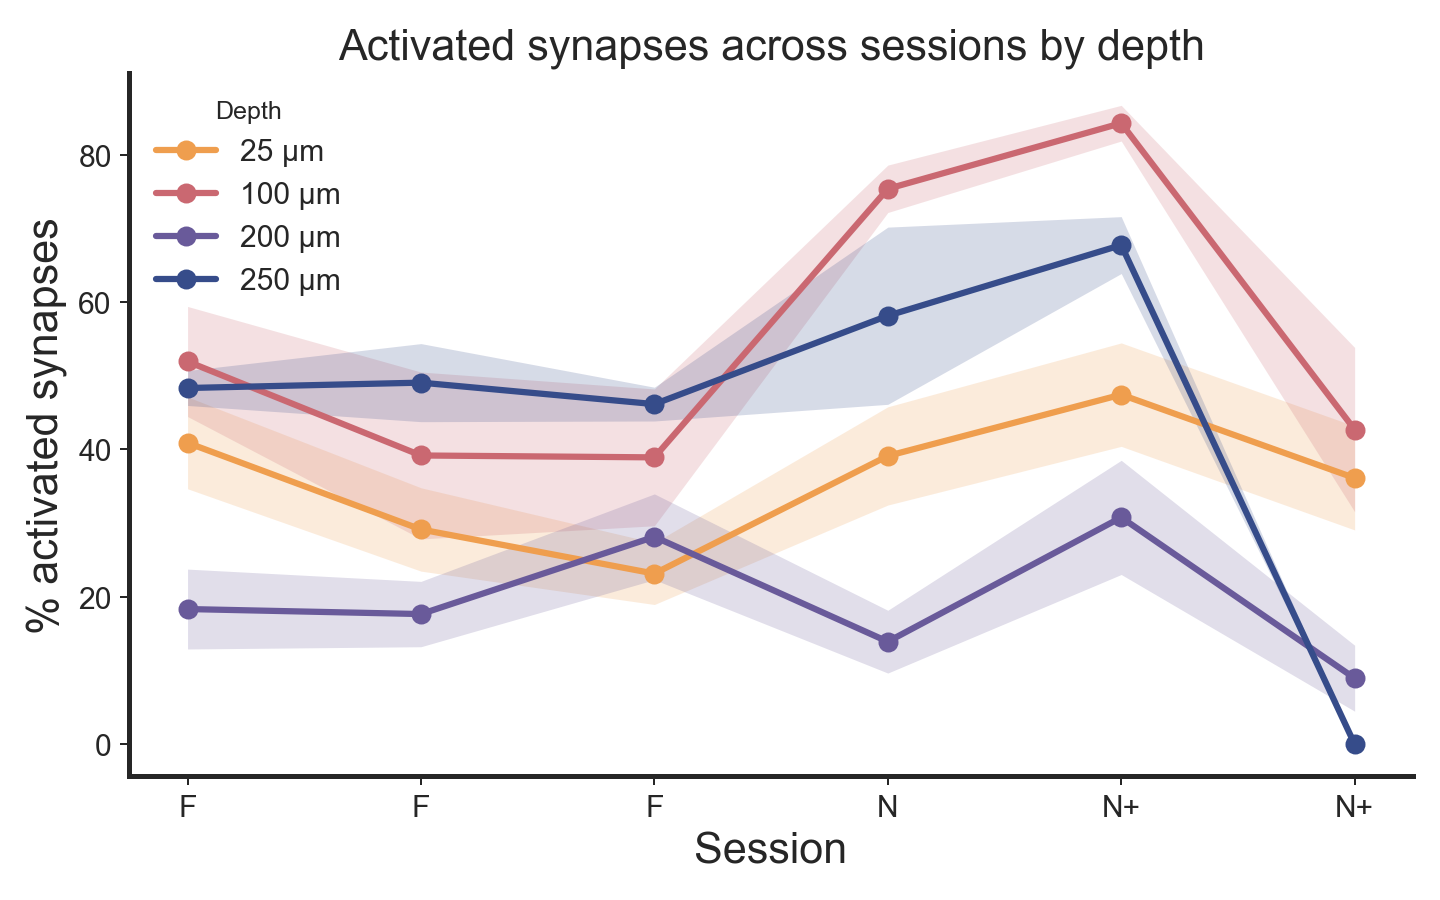

In [65]:
# -----------------------------------------
# summarize across animals with SEM
# -----------------------------------------
summary = (
    animal_slot_depth
    .groupby(["session_slot", "depth_um"], as_index=False)
    .agg(
        mean_pct=("pct_activated", "mean"),
        sd_pct=("pct_activated", "std"),
        n_animals=("pct_activated", "count"),
    )
)

summary["sem_pct"] = summary["sd_pct"] / np.sqrt(summary["n_animals"])

summary["session_slot"] = pd.Categorical(
    summary["session_slot"],
    categories=slot_order,
    ordered=True,
)
summary = summary.sort_values(["depth_um", "session_slot"])

# -----------------------------------------
# plot with SEM as fill_between
# -----------------------------------------
fig, ax = plt.subplots(figsize=(8, 5))

sns.despine()

ax.tick_params(axis='x', which='major', reset=True, top=False, labelsize=12)
ax.tick_params(axis='y', which='major', reset=True, right=False, labelsize=12)

xpos = np.arange(len(slot_order))
xmap = dict(zip(slot_order, xpos))

for depth in depth_order:
    sub = summary[summary["depth_um"] == depth].copy()
    if sub.empty:
        continue

    x = sub["session_slot"].map(xmap).to_numpy(dtype=float)
    y = sub["mean_pct"].to_numpy(dtype=float)
    sem = sub["sem_pct"].to_numpy(dtype=float)

    ax.plot(
        x,
        y,
        lw=2.5,
        marker="o",
        ms=7,
        color=depth_color_map[depth],
        label=f"{depth} µm",
    )

    ax.fill_between(
        x,
        y - sem/2,
        y + sem/2,
        color=depth_color_map[depth],
        alpha=0.2,
        linewidth=0,
    )

ax.set_xticks(xpos)
ax.set_xticklabels(["F", "F", "F", "N", "N+", "N+"])
ax.set_xlabel("Session")
ax.set_ylabel("% activated synapses")
ax.set_title("Activated synapses across sessions by depth")
ax.legend(frameon=False, title="Depth",fontsize=12)

for spine in ['left','bottom']:
    ax.spines[spine].set_linewidth(2)

fig.tight_layout()
filen = f"PctActivated_ByDepth_AcrossSessions"
savepath = os.path.join(save_path, "Figures", filen)
# save_figure(fig, savepath, formats=[".pdf", ".png"], dpi=300)